## Import Library

In [9]:
# 202431111_Rendy
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Membaca dan Mengubah Gambar ke Grayscale

In [2]:
# 202431111_Rendy
citra_m = cv2.imread("ikea.jpg")
citra_m = cv2.cvtColor(citra_m, cv2.COLOR_BGR2GRAY)

## Menampilkan Gambar

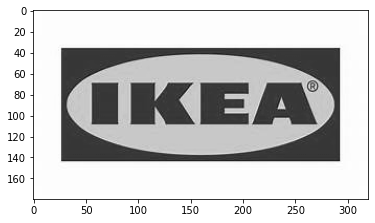

In [3]:
# 202431111_Rendy
plt.imshow(citra_m, cmap = "gray")
plt.show()

## Mempersiapkan Avarage Filter

In [4]:
# 202431111_Rendy
copyCitra1 = citra_m.copy().astype(float)

m1, n1 = copyCitra1.shape
output1 = np.empty([m1, n1])

print("Shape copy citra 1 : ", copyCitra1.shape)
print("Shape output citra 1 : ", output1.shape)

print("m1 : ", m1)
print("n1 : ", n1)

print()

Shape copy citra 1 :  (180, 320)
Shape output citra 1 :  (180, 320)
m1 :  180
n1 :  320



## Avarage Filter

In [5]:
# 202431111_Rendy
for baris in range(0, m1-1):
    for kolom in range(0, n1-1):
        a1 = baris
        b1 = kolom
        jumlah = copyCitra1[a1-1, b1-1] + copyCitra1[a1-1, b1] + copyCitra1[a1-1, b1+1] +\
        copyCitra1[a1, b1-1] + copyCitra1[a1, b1] + copyCitra1[a1, b1+1] +\
        copyCitra1[a1+1, b1-1] + copyCitra1[a1+1, b1] + copyCitra1[a1+1, b1+1]
        output1[a1, b1] = (1/9 * jumlah)
        
# Konversi ke uint8
output1 = np.asarray(output1, dtype = np.uint8)

## Menampilkan Hasil Average Filter

Text(0.5, 1.0, 'Input Citra 2')

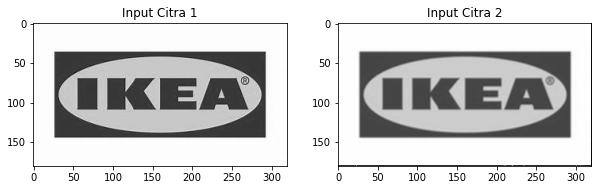

In [6]:
# 202431111_Rendy
fig, axs = plt.subplots(1, 2, figsize=(10,10))
ax = axs.ravel()

ax[0].imshow(citra_m, cmap = "gray")
ax[0].set_title('Input Citra 1')

ax[1].imshow(output1, cmap = "gray")
ax[1].set_title('Input Citra 2')

## Median Filter

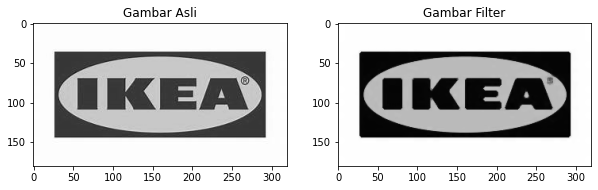

In [7]:
# 202431111_Rendy
citra_m2 = citra_m
img_median = citra_m2.copy()
img_median_after = cv2.medianBlur(img_median, 5)

fig, axs = plt.subplots(1,2, figsize=(10,10))
ax = axs.ravel()

ax[0].imshow(img_median, cmap="gray")
ax[0].set_title("Gambar Asli")

ax[1].imshow(img_median_after, cmap="gray")
ax[1].set_title("Gambar Filter")

plt.show()

## Filter Batas

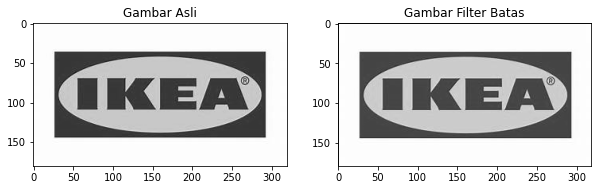

In [8]:
# 202431111_Rendy
citra_m3 = citra_m
copyCitra3 = citra_m3.copy().astype(float)

m1,n1 = copyCitra3.shape
output3 = np.empty([m1-1, n1-1])

for baris in range(1, m1-1):
    for kolom in range(1, n1-1):
        a1 = baris
        b1 = kolom
        arr = np.array([copyCitra3[a1-1, b1-1], copyCitra3[a1-1, b1], copyCitra3[a1-1, b1+1],
              copyCitra3[a1, b1-1], copyCitra3[a1, b1+1],
              copyCitra3[a1+1, b1-1], copyCitra3[a1+1, b1], copyCitra3[a1+1, b1+1]])
        
        minPiksel = np.amin(arr)
        maxPiksel = np.amax(arr)
        
        if (copyCitra3[baris, kolom] < minPiksel):
            output3[baris, kolom] = minPiksel
        else :
            if (copyCitra3[baris, kolom] > maxPiksel):
                output3[baris, kolom ] = maxPiksel
            else :
                output3[baris, kolom] = copyCitra3[baris, kolom]
                
output3 = np.asarray(output3, dtype=np.uint8)

fig, axs = plt.subplots(1,2, figsize = (10,10))
ax = axs.ravel()

ax[0].imshow(citra_m3, cmap="gray")
ax[0].set_title("Gambar Asli")

ax[1].imshow(output3, cmap="gray")
ax[1].set_title("Gambar Filter Batas")

plt.show()